<a href="https://colab.research.google.com/github/mariadelmarhernandezh-ai/integracion2026/blob/main/Reto_1_Integracionistas_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CASO DE ESTUDIO**
Modelamiento del riesgo derivado de las operaciones del negocio de una FINTECH

Una FINTECH quiere estimar las perdidas asociadas con el riesgo derivado de los fallos tecnologicos en transacciones de sus clientes a traves de sus canales electronicos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nxl= '/content/drive/MyDrive/Integracion de datos y prospectiva/1. FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head(10)

Mounted at /content/drive


,Fallas Tecnológicas (Canales Electronicos),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas (Freq),Valor Generado Promedio (Millones),Descripción Evento
1,2009-01-01 00:00:00,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
2,2009-01-02 00:00:00,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
3,2009-01-03 00:00:00,70,9.976,5,0.4269,"Errores visuales menores, problemas de usabili..."
4,2009-01-04 00:00:00,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
5,2009-01-05 00:00:00,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."
6,2009-01-06 00:00:00,100,31.5177,3,0.2363,"Errores visuales menores, problemas de usabili..."
7,2009-01-07 00:00:00,115,29.5603,1,0.2737,"Errores visuales menores, problemas de usabili..."
8,2009-01-08 00:00:00,90,36.4063,8,12.4245,"Caída total del sistema por más de 24 horas, p..."
9,2009-01-09 00:00:00,105,9.3552,1,2.3869,"Degradación del rendimiento por varias horas, ..."


Distribucion agregada de perdidas

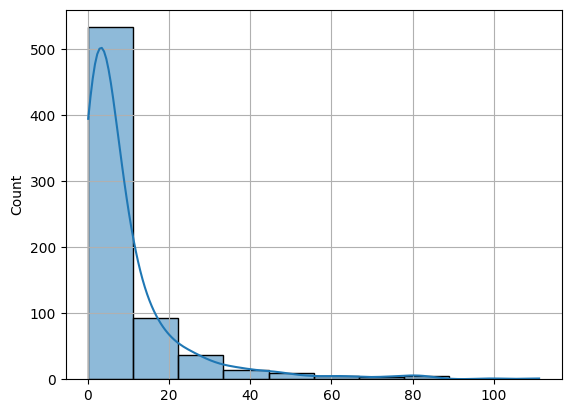

In [3]:
Freq=pd.to_numeric(XDB.iloc[1:,3])
Sev=pd.to_numeric(XDB.iloc[1:,4])
LDA=Freq*Sev

#Construccion de la distribucion agregada de las perdidas
plt.figure() #grafica
sns.histplot(LDA,bins=10,kde=True)
plt.grid()
plt.show()

Clusterizacion estadistica definida por el histograma de frecuencias.
Calculo de metricas estadisticas de tendencia central y dispersion: Media, Desviacion, Asimetria y Kurtosis

In [4]:
u=np.mean(LDA)
varianza=np.var(LDA)
sigma=np.std(LDA)

Tabla2=np.column_stack((u,varianza,sigma))
DataFrame2=pd.DataFrame(Tabla2,columns=['Media', 'Varianza', 'Desviacion'])

from scipy.stats import skew, kurtosis

#Calcular asmiteroa
Ida_skew=skew(LDA)

#Calcular kurtosis
Ida_kurt=kurtosis(LDA)

#añadir al data frame las metricas faltantes
DataFrame2['Asimetria']=Ida_skew
DataFrame2['Kurtosis']=Ida_kurt
display(DataFrame2)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


La fintech quiere hacer un muestreo de las variables aleatorias de frecuencia y severidad a una confiabilidad del 99,9% utilizando el metodo de montecarlo

In [8]:
from scipy.stats import poisson, lognorm, skew, kurtosis

Freq = pd.to_numeric(XDB.iloc[1:,3], errors='coerce').dropna()
Sev  = pd.to_numeric(XDB.iloc[1:,4], errors='coerce').dropna()

N_sim = 100000  # simulaciones
losses = []

lambda_freq = Freq.mean()

shape, loc, scale = lognorm.fit(Sev, floc=0)

for _ in range(N_sim):
    # Número de fallas en la simulación
    N = poisson.rvs(mu=lambda_freq)

    # Si no hubo fallas la pérdida es 0
    if N == 0:
        losses.append(0)
    else:
        # Generar N severidades y sumarlas
        severidades = lognorm.rvs(shape, loc=loc, scale=scale, size=N)
        losses.append(severidades.sum())

losses = np.array(losses)
losses

array([3.82098873, 8.68908252, 5.24385528, ..., 2.62797082, 6.86261685,
       4.35546286])

Distribucion agregada de perdidas

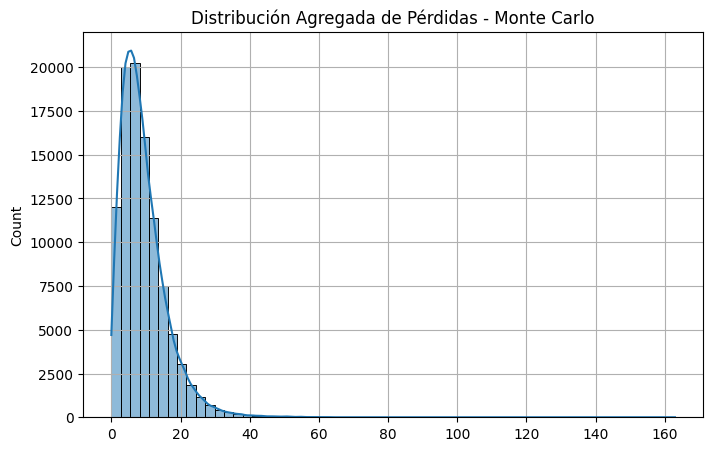

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(losses, bins=60, kde=True)
plt.title("Distribución Agregada de Pérdidas - Monte Carlo")
plt.grid()
plt.show()

In [10]:
media = np.mean(losses)
varianza = np.var(losses, ddof=1)
desv = np.std(losses, ddof=1)
asimetria = skew(losses)
curtosis = kurtosis(losses)

metricas = pd.DataFrame({
    'Media': [media],
    'Varianza': [varianza],
    'Desviación': [desv],
    'Asimetría': [asimetria],
    'Curtosis': [curtosis]
})

display(metricas)

,Media,Varianza,Desviación,Asimetría,Curtosis
0,9.263602,45.771083,6.765433,1.926434,10.425142


Calcular valor en riesgo

In [11]:
VaR_999 = np.percentile(losses, 99.9)
VaR_99 = np.percentile(losses, 99)
perdida_esperada = media
perdida_no_esperada = VaR_999 - media
perdida_catastrófica = VaR_999

tabla_final = pd.DataFrame({
    'Pérdida Esperada (EL)': [perdida_esperada],
    'Pérdida No Esperada (UL)': [perdida_no_esperada],
    'Pérdida Catastrófica (VaR 99.9%)': [perdida_catastrófica]
})

display(tabla_final)


,Pérdida Esperada (EL),Pérdida No Esperada (UL),Pérdida Catastrófica (VaR 99.9%)
0,9.263602,41.431916,50.695518
